# Bias, Variance, and Regularization

In our previous lesson, we saw how a Decision Tree could mathematically contort itself to draw a tiny box around every single outlier in a dataset. It achieved perfect accuracy on its training data, but it would fail catastrophically in production. 

This phenomenon introduces the most fundamental theorem in all of Machine Learning: **The Bias-Variance Tradeoff**. 

In this lesson, we will formally define what it means for a model to "memorize" versus "learn," and we will introduce **Regularization**—the mathematical penalty we apply to algorithms to force them to remain simple, generalized, and robust.

Every time you train a machine learning algorithm, you are battling two competing forces of error. You cannot completely eliminate both. To decrease one, you must often increase the other. 

Let's set up our Python environment to visualize this mathematical tug-of-war.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Optimization & Regularization Environment Ready.")

✅ Optimization & Regularization Environment Ready.


# 1. The Bias-Variance Tradeoff

When a model makes a prediction, its total error can be mathematically decomposed into three distinct parts:
$$Total\_Error = Bias^2 + Variance + Irreducible\_Error$$

*   **Irreducible Error**: The natural noise in the universe. No algorithm can predict a completely random event. We cannot fix this.
*   **Bias (Underfitting)**: The error introduced by approximating a highly complex real-world problem with an overly simplistic mathematical model. A model with High Bias pays very little attention to the training data and oversimplifies reality (e.g., using a straight line to predict a curved trend).
*   **Variance (Overfitting)**: The error introduced by a model being *too* sensitive to the tiny fluctuations (noise) in the training data. A model with High Variance models the random noise rather than the intended outputs (e.g., a massive Decision Tree memorizing outliers).

**The Objective:** We must find the "Sweet Spot"—a model complex enough to capture the underlying business trend (Low Bias), but constrained enough to ignore the random noise (Low Variance).

# 2. Visualizing Underfitting vs. Overfitting

Let's simulate a corporate dataset representing **Server CPU Temperature over 24 Hours**. The true underlying physics follows a smooth wave, but our sensors have random electrical noise.

We will fit three models: a straight line (Degree 1), a perfect wave (Degree 3), and a wildly complex curve (Degree 15).

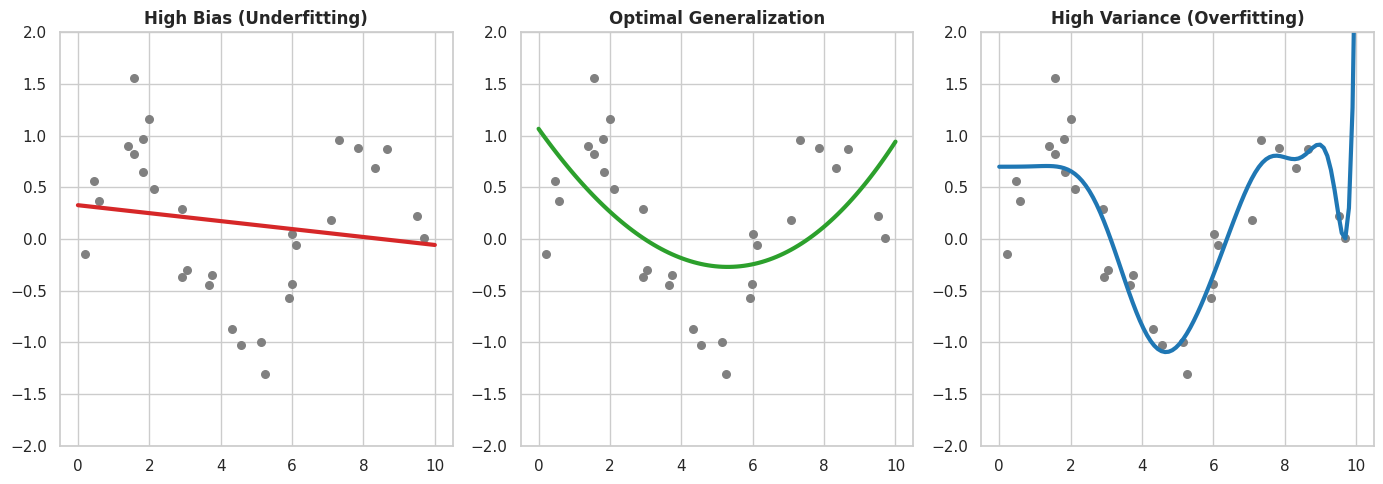

In [2]:
# 1. Simulate noisy server temperature data (True underlying pattern is a Sine Wave)
np.random.seed(42)
X = np.sort(np.random.rand(30) * 10) # 30 sensor readings over 10 hours
y_true_physics = np.sin(X) 
y_noisy = y_true_physics + np.random.randn(30) * 0.3 # Add sensor noise

X_reshaped = X.reshape(-1, 1)
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)

# 2. Train three models with varying mathematical complexity
# Model A: High Bias (Underfit) - Straight Line
model_underfit = LinearRegression()
model_underfit.fit(X_reshaped, y_noisy)

# Model B: The Sweet Spot (Optimal Generalization) - Degree 3
model_optimal = make_pipeline(PolynomialFeatures(3), LinearRegression())
model_optimal.fit(X_reshaped, y_noisy)

# Model C: High Variance (Overfit) - Degree 15
model_overfit = make_pipeline(PolynomialFeatures(15), LinearRegression())
model_overfit.fit(X_reshaped, y_noisy)

# 3. Matplotlib Visualization
plt.figure(figsize=(14, 5))

# Plot 1: Underfitting (Bias)
plt.subplot(1, 3, 1)
plt.scatter(X, y_noisy, color='gray', s=30, label='Sensor Data')
plt.plot(X_plot, model_underfit.predict(X_plot), color='#d62728', linewidth=3)
plt.title("High Bias (Underfitting)", fontweight='bold')
plt.ylim(-2, 2)

# Plot 2: Sweet Spot (Generalization)
plt.subplot(1, 3, 2)
plt.scatter(X, y_noisy, color='gray', s=30)
plt.plot(X_plot, model_optimal.predict(X_plot), color='#2ca02c', linewidth=3)
plt.title("Optimal Generalization", fontweight='bold')
plt.ylim(-2, 2)

# Plot 3: Overfitting (Variance)
plt.subplot(1, 3, 3)
plt.scatter(X, y_noisy, color='gray', s=30)
plt.plot(X_plot, model_overfit.predict(X_plot), color='#1f77b4', linewidth=3)
plt.title("High Variance (Overfitting)", fontweight='bold')
plt.ylim(-2, 2)

plt.tight_layout()
plt.show()

*(Insight: Look at the third plot. The algorithm created an equation so complex that it physically hit almost every single gray dot. It thinks the random electrical sensor noise is an actual temperature spike. If we deploy that blue line into tomorrow's data, it will fail miserably.)*

# 3. The Mathematics of Regularization (Ridge vs. Lasso)

How do we stop an algorithm from building that wild blue curve? We use **Regularization**.

Regularization artificially alters the Cost Function $J(\theta)$. Instead of just trying to minimize the Mean Squared Error (MSE), we add a mathematical "penalty" for complexity. We force the algorithm to keep its weights ($\theta$) as small as possible.

### 1. Ridge Regression (L2 Regularization)
Ridge adds a penalty equal to the **square of the magnitude** of the coefficients.
$$J(\theta) = \text{MSE} + \alpha \sum_{j=1}^{m} \theta_j^2$$
*   $\alpha$ (Alpha/Lambda) controls the strength of the penalty.
*   **Effect:** It shrinks all parameters down smoothly, preventing any single feature from having a massive, chaotic impact on the prediction. It smooths out wild curves.

### 2. Lasso Regression (L1 Regularization)
Lasso adds a penalty equal to the **absolute value** of the magnitude of coefficients.
$$J(\theta) = \text{MSE} + \alpha \sum_{j=1}^{m} |\theta_j|$$
*   **Effect:** Because of the geometry of absolute values, Lasso actually shrinks less important parameters to **exact mathematical zero**. It performs automatic feature selection, entirely deleting useless columns from your dataset.

# 4. Taming the Variance in Code

Let's take our wildly overfitted Degree 15 Polynomial (the blue curve) and apply Ridge Regularization to it. Watch how the mathematics forcibly flatten the curve back into reality.

/root/micromamba/envs/ds/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.54673e-28): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


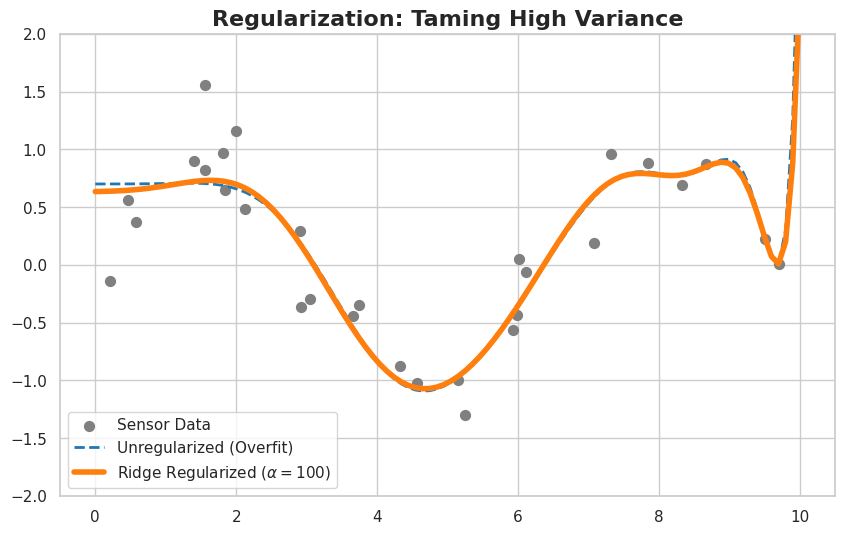

In [3]:
# Train a heavily Regularized model on the exact same Degree 15 features
# alpha=100 applies a massive penalty to complex weights
model_ridge = make_pipeline(PolynomialFeatures(15), Ridge(alpha=100))
model_ridge.fit(X_reshaped, y_noisy)

plt.figure(figsize=(10, 6))
plt.scatter(X, y_noisy, color='gray', s=50, label='Sensor Data')

# Plot the Unregularized Overfit model
plt.plot(X_plot, model_overfit.predict(X_plot), color='#1f77b4', linewidth=2, linestyle='--', label='Unregularized (Overfit)')

# Plot the Regularized model
plt.plot(X_plot, model_ridge.predict(X_plot), color='#ff7f0e', linewidth=4, label=r'Ridge Regularized ($\alpha=100$)')

plt.title("Regularization: Taming High Variance", fontsize=16, fontweight='bold')
plt.ylim(-2, 2)
plt.legend()
plt.show()

*(Insight: Both the dashed blue line and the solid orange line were trained on the exact same 15-degree polynomial features. But because we added $\alpha = 100$ to the Ridge model, the optimization engine was mathematically barred from using massive weights. The orange curve was forced to stay smooth, saving the model from overfitting!)*

---

## Real-World Use Case or Analogy:
Think of the Bias-Variance Tradeoff like **A Student Studying for a Final Exam**:

*   **High Bias (Underfitting)**: The student studies for exactly 5 minutes. They walk into the exam, look at the complex questions, and write "C" for every single answer. They oversimplified the problem.
*   **High Variance (Overfitting)**: The student gets a copy of the 2023 Practice Exam. They memorize the exact letter answers in order: A, B, C, D, A... They do not learn *why* the answers are correct. If the professor hands out the 2024 Exam and changes exactly one number in question 1, the student's entire memorized sequence fails catastrophically.
*   **Regularization**: The professor limits the student to a 1-page cheat sheet. The student cannot fit the entire 2023 practice exam on one page (preventing memorization/overfitting). They are forced to synthesize the core formulas and general concepts (Ridge), crossing out trivial details that don't matter (Lasso).

---